### Initial actions

In [1]:
import os
from huggingface_hub import login
from tqdm.notebook import tqdm


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image
import random

In [3]:
seed_value = 42
rng = np.random.default_rng(seed_value)
random.seed(seed_value)

In [4]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [5]:
# for running in google colab
# from huggingface_hub import login
# from google.colab import userdata

# HF_TOKEN = userdata.get('HF_TOKEN')

# # Log in to Hugging Face Hub
# if HF_TOKEN:
#     login(HF_TOKEN)
#     print("Successfully logged in to Hugging Face!")
# else:
#     print("HF_TOKEN is not set in Colab secrets.")

### First load and test VLM model

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-256M-Instruct")
model = AutoModelForImageTextToText.from_pretrained(
    "HuggingFaceTB/SmolVLM-256M-Instruct",
    dtype=torch.bfloat16
).to(DEVICE)

def generate_text(images, raw_prompt):
  # Prepare inputs
  prompt = processor.apply_chat_template(raw_prompt, add_generation_prompt=True)
  inputs = processor(text=prompt, images=images, return_tensors="pt")
  inputs = inputs.to(DEVICE)

  # Generate outputs
  generated_ids = model.generate(**inputs, max_new_tokens=500)
  generated_texts = processor.batch_decode(
      generated_ids,
      skip_special_tokens=True,
  )

  return generated_texts[0]

image = load_image("https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Can you describe this image?"}
        ]
    },
]

generate_text([image], messages)

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

"User:\n\n\n\nCan you describe this image?\nAssistant: The image depicts a large, historic statue of liberty, located in New York City. The statue is a green, cylindrical statue of liberty, which is a figure of liberty, a symbol of freedom and autonomy. The statue is situated on a pedestal, which is a round, flat structure that supports the statue. The pedestal is surrounded by a ring of scaffolding, which is used to support the statue.\n\nIn the background, there is a large body of water, which is likely the Hudson River. The water is calm, with small ripples indicating that it is likely a sunny day. The sky is clear, with a few clouds visible, suggesting that it is a sunny day.\n\nTo the left of the statue, there is a small, green tree, which is part of the natural landscape. The tree is located on the left side of the image, and it is surrounded by a small patch of grass.\n\nThe statue is surrounded by a large, open area, which is likely a park or a plaza. The area is filled with tr

### Load datasets

In [7]:
from datasets import load_dataset

train_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="train")
val_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="validation")
test_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="test")

In [8]:
# train_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split="train")
# train_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split="validation")
# train_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split="test")

### Test model

In [9]:
from IPython.display import display, Math

In [10]:
image = train_dataset_linxy[0]['image']

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this handwritten formula to LaTeX"}
        ]
    },
]

answer = generate_text(image, messages)
print(answer)
print('-----------------------------------')
print('Example: ')
print(train_dataset_linxy[0]['text'])

User:

Convert this handwritten formula to LaTeX
Assistant: z_{1}=r_{1}cos\theta_{1}
-----------------------------------
Example: 
z _ { 1 } = r _ { 1 } ( \cos \theta _ { 1 } + i \sin \theta _ { 1 } )


In [11]:
display(Math(train_dataset_linxy[0]['text']))

<IPython.core.display.Math object>

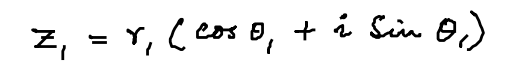

In [12]:
image

In [13]:
substring = 'Assistant: '
index = answer.find(substring)
if index != -1:
  display(Math(answer[index+len(substring):]))

<IPython.core.display.Math object>

### Calculate metrics for zero-shot inference

In [14]:
answer[index+len(substring):]

'z_{1}=r_{1}cos\\theta_{1}'

In [15]:
from rouge_score import rouge_scorer
import sacrebleu
import jiwer
from tqdm.notebook import tqdm

def evaluate_model(test_dataset, scoring='cer', examples=None, mode='_0shot'):
  scores = []
  loop = tqdm(test_dataset, desc=f"Processing {mode}", leave=True)

  # prepare prompt for the model
  base_prompt_text = "Convert this handwritten formula to LaTeX. \
Output ONLY the LaTeX code, nothing else."
  if mode == '_0shot':
    prompt = [
      {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": base_prompt_text}
        ]
      },
    ]
  elif mode == '_1shot':
    if examples is None:
      raise ValueError("Для one-shot нужен examples для выбора примера!")

    example_item = examples[0]
    example_image = example_item['image']
    example_text = example_item['text'].replace(" ", "")

    prompt = [
      {
        "role": "user",
        "content": [
            {"type": "image"}, # example_image
            {"type": "text", "text": base_prompt_text}
        ]
      },
      {
        "role": "assistant",
        "content": [
            {"type": "text", "text": example_text}
        ]
      },
      {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": base_prompt_text}
        ]
      }
    ]
  else:
    raise ValueError("Неизвестный mode! Используйте '_0shot' или '_1shot'")

  # loop for calculating metric
  for item in loop:
    image = item['image']
    text = item['text'].replace(" ", "")

    if mode == '_0shot':
      answer = generate_text([image], prompt)
    elif mode == '_1shot':
      answer = generate_text([example_image, image], prompt)

    substring = 'Assistant: '
    index = answer.rfind(substring)
    if index == -1:
      index = 0
    prediction = answer[index+len(substring):]
    reference = text


    # Initialize and calculate scores
    score = 0
    if scoring == 'rouge':
      rogueL = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
      rogueL_scores = rogueL.score(prediction, reference)
      score = rogueL_scores['rougeL'][2]
    elif scoring == 'bleu':
      prediction = [prediction]
      reference = [[reference]]
      bleu = sacrebleu.corpus_bleu(prediction, reference)
      score = bleu.score
    elif scoring == 'cer':
      score = jiwer.cer(reference, prediction)
    else:
      raise ValueError('Error: Unknown type of score')
    scores.append(score)
    # print("REFERENCE: ", reference)
    # display(Math(reference))
    # print()
    # print("PREDICTION: ", prediction)
    # display(Math(prediction))
    # print(score)
  scores = np.array(scores)
  return scores.mean()

In [16]:
# zero_shot_metrics = {'cer': 0., 'bleu': 0., 'rouge': 0.}
zero_shot_metrics = {'cer': 0.}
for metric in zero_shot_metrics.keys():
  print('Calculating metric: ', metric)
  value = evaluate_model(test_dataset_linxy, scoring=metric, mode='_0shot')
  zero_shot_metrics[metric] = value
  print(f"{metric} = {value}")
  print('-----------------------------------------')

Calculating metric:  cer


Processing _0shot:   0%|          | 0/70 [00:00<?, ?it/s]

cer = 0.17520846942852333
-----------------------------------------


### Calculate metrics for one-shot inference

In [17]:
# @title
train_examples = [train_dataset_linxy[0]]
# one_shot_metrics = {'cer': 0., 'bleu': 0., 'rouge': 0.}
one_shot_metrics = {'cer': 0.}
for metric in zero_shot_metrics.keys():
  print('Calculating metric: ', metric)
  value = evaluate_model(test_dataset_linxy, scoring=metric, examples=train_examples, mode='_1shot')
  zero_shot_metrics[metric] = value
  print(f"{metric} = {value}")
  print('-----------------------------------------')

Calculating metric:  cer


Processing _1shot:   0%|          | 0/70 [00:00<?, ?it/s]

cer = 0.17054731227961065
-----------------------------------------


### Supervised fine-tuning (SFT) using linxy/LaTeX_OCR:train

#### Small VLM (SmolVLM-256M-Instruct)

In [18]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"
HF_REPO = "Azaper/smolvlm-latex-ocr"

def generate_text_SFT(raw_prompt, images, model, processor, device=DEVICE, max_new_tokens=512):
  # Prepare inputs
  prompt = processor.apply_chat_template(raw_prompt, add_generation_prompt=True)
  inputs = processor(text=prompt, images=images, return_tensors="pt")
  inputs = inputs.to(device)

  # Generate outputs
  generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
  generated_texts = processor.batch_decode(
      generated_ids,
      skip_special_tokens=True,
  )

  return generated_texts[0]

In [19]:
from datasets import load_dataset, concatenate_datasets

user_prompt = "Convert this handwritten formula to LaTeX code. Output ONLY the LaTeX, nothing else."

# Форматируем под chat-шаблон
def format_example(example):
    return {
        "messages": [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": user_prompt}
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": example["text"]}]}
        ],
        "images": [example["image"]]
    }

train_ds1 = train_dataset_linxy.map(format_example, remove_columns=train_dataset_linxy.column_names)
eval_ds1 = val_dataset_linxy.map(format_example, remove_columns=val_dataset_linxy.column_names)
test_ds1 = test_dataset_linxy.map(format_example, remove_columns=test_dataset_linxy.column_names)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

In [24]:
from transformers import BitsAndBytesConfig
from transformers import Idefics3ForConditionalGeneration
from trl import SFTTrainer, SFTConfig
from unsloth import FastVisionModel
from unsloth import is_bf16_supported

# Load model and tokenizer
model, processor = FastVisionModel.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if is_bf16_supported() else torch.float16,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing=True,
    random_state=42,
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18500\1785809062.py:4: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


AttributeError: module 'torch' has no attribute 'int1'

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=processor,
    train_dataset=train_ds1,
    eval_dataset=eval_ds1,
    dataset_text_field="messages",
    max_seq_length=1024,
    dataset_num_proc=2,
    packing=False,

    args=SFTConfig(
        output_dir="./temp_unsloth",
        push_to_hub=True,
        hub_model_id="Azaper/smolvlm-latex-ocr",
        hub_strategy="every_save",
        hub_private_repo=False,
        save_strategy="no",
        save_steps=0,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=16,
        warmup_steps=10,
        max_steps=400,
        learning_rate=2e-4,
        bf16=is_bf16_supported(),
        fp16=not is_bf16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=seed_value,
    ),
)

trainable params: 3,067,776 || all params: 259,552,704 || trainable%: 1.1819


In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.


Step,Training Loss


In [ ]:
model.push_to_hub_merged(
    repo_id="Azaper/smolvlm-latex-ocr",
    tokenizer=processor,
    save_method="merged_16bit",
    token=True
)

processor.push_to_hub("Azaper/smolvlm-latex-ocr")
print("Модель полностью загружена на HF!")